In [3]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['NanumGothic']


# C-MAPSS

Kaggle에서 원본 다운로드 가능
https://www.kaggle.com/datasets/canyiduan/nasa-c-mapss$0

NASA의 **C-MAPSS(Commercial Modular Aero-Propulsion System Simulation) 데이터셋**은 항공기 터보팬 엔진의 열화 및 고장 과정을 시뮬레이션하여 생성한 대표적인 시계열 벤치마크 데이터셋입니다. 산업 인공지능 분야의 **예지보전(Predictive Maintenance, PdM)** 및 **잔여 수명 예측(RUL, Remaining Useful Life)** 연구에서 사실상의 표준(De facto standard)으로 널리 쓰입니다.

---

**1. 데이터 개요 및 구성**

* **데이터 형태:** 다변량 시계열(Multivariate Time-series) 데이터
* **기록 변수:** 엔진 ID, 운용 사이클(Time/Cycle), 운용 설정값 3종(고도, 마하 수, 스로틀 등), 센서 측정값 21종(온도, 압력, 팬 속도 등)
* **기본 구조:** 엔진이 정상 상태에서 가동을 시작해 시간이 지남에 따라 점진적으로 마모되어 완전한 고장(Failure)에 도달할 때까지의 데이터가 사이클 단위로 기록되어 있습니다.

**2. 4가지 서브 데이터셋 (FD001 ~ FD004)**
C-MAPSS는 운용 환경과 고장 모드 조합에 따라 난이도가 다른 4개의 하위 데이터셋으로 나뉩니다.

| 데이터셋 | 운용 조건 수 (Conditions) | 고장 모드 (Fault Modes) | 난이도 / 특징 |
| --- | --- | --- | --- |
| **FD001** | 1개 (해수면 고정) | 1개 (HPC 열화) | 가장 단순한 베이스라인 |
| **FD002** | 6개 (복합 비행 조건) | 1개 (HPC 열화) | 다양한 운용 환경 반영 |
| **FD003** | 1개 (해수면 고정) | 2개 (HPC + Fan 열화) | 복수 고장 원인 분석 |
| **FD004** | 6개 (복합 비행 조건) | 2개 (HPC + Fan 열화) | 실제와 가장 유사한 복합 조건 |

*(HPC: High Pressure Compressor, 고압 압축기)*

**3. 연구 활용 목적**

* **RUL(잔여 수명) 예측:** 테스트 셋의 엔진이 고장나기 전까지 몇 사이클이 더 남아있는지 추정.
* **이상 탐지 및 고장 진단:** 정상 신호 패턴에서 벗어나는 시점을 조기에 감지하고 고장 모드를 분류.





## 실습 1. C-MAPSS 데이터 열고 구조 확인
- 샘플을 직접 열어 크기와 열 구성을 파악
목표
- 강사가 준 엔진 데이터를 직접 열어 크기와 열 구성을 파악

단계
- pandas를 불러와 샘플 파일을 데이터프레임으로 열기
- 크기 속성으로 행·열 개수를, 열 이름 속성으로 컬럼을 확인
- 앞부분을 미리 보며 값의 모양을 눈으로 익히기

예상 결과
- 행 천여 개·스물여섯 열, 엔진번호·작동회차·센서 열이 보임

In [4]:
df = pd.read_csv('20_cmapss_fd001_sample.csv')
print(df.shape)
df.info()

(1116, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_nr      1116 non-null   int64  
 1   time_cycles  1116 non-null   int64  
 2   setting_1    1116 non-null   float64
 3   setting_2    1116 non-null   float64
 4   setting_3    1116 non-null   float64
 5   s_1          1116 non-null   float64
 6   s_2          1116 non-null   float64
 7   s_3          1116 non-null   float64
 8   s_4          1116 non-null   float64
 9   s_5          1116 non-null   float64
 10  s_6          1116 non-null   float64
 11  s_7          1116 non-null   float64
 12  s_8          1116 non-null   float64
 13  s_9          1116 non-null   float64
 14  s_10         1116 non-null   float64
 15  s_11         1116 non-null   float64
 16  s_12         1116 non-null   float64
 17  s_13         1116 non-null   float64
 18  s_14         1116 non-null   float64


In [5]:
print(df.head())

   unit_nr  time_cycles  setting_1  setting_2  setting_3     s_1     s_2  \
0        1            1     0.0010    -0.0000      100.0  518.67  641.17   
1        1            2     0.0006    -0.0003      100.0  518.67  640.66   
2        1            3     0.0016    -0.0004      100.0  518.67  641.08   
3        1            4    -0.0008    -0.0002      100.0  518.67  641.18   
4        1            5     0.0007    -0.0002      100.0  518.67  641.13   

       s_3      s_4    s_5  ...    s_12     s_13     s_14   s_15  s_16  s_17  \
0  1589.63  1399.16  14.62  ...  520.73  2387.98  8132.98  8.344  0.03   391   
1  1589.52  1399.28  14.62  ...  521.11  2387.97  8126.66  8.385  0.03   394   
2  1579.31  1394.97  14.62  ...  520.15  2387.97  8124.71  8.436  0.03   392   
3  1588.34  1404.10  14.62  ...  520.76  2387.95  8115.96  8.430  0.03   393   
4  1589.93  1400.33  14.62  ...  520.86  2387.91  8127.75  8.417  0.03   393   

   s_18   s_19   s_20     s_21  
0  2388  100.0  38.85  23.246

In [6]:
print(df.describe())

           unit_nr  time_cycles    setting_1    setting_2  setting_3  \
count  1116.000000  1116.000000  1116.000000  1116.000000     1116.0   
mean      3.050179   116.698925    -0.000068     0.000002      100.0   
std       1.441595    72.255767     0.001989     0.000301        0.0   
min       1.000000     1.000000    -0.006500    -0.000900      100.0   
25%       2.000000    56.000000    -0.001400    -0.000200      100.0   
50%       3.000000   112.000000    -0.000100     0.000000      100.0   
75%       4.000000   168.000000     0.001300     0.000200      100.0   
max       5.000000   287.000000     0.006400     0.000900      100.0   

                s_1          s_2          s_3          s_4           s_5  ...  \
count  1.116000e+03  1116.000000  1116.000000  1116.000000  1.116000e+03  ...   
mean   5.186700e+02   641.759973  1591.205681  1409.185699  1.462000e+01  ...   
std    7.961646e-13     0.497618     4.573376     6.393228  3.518763e-13  ...   
min    5.186700e+02   640.2

In [7]:
# 결측 있을까?
print(df.isna().sum().sum())

0


## 실습 2. 엔진 단위와 작동 길이 파악
여러 엔진이 섞인 구조와 엔진별 작동 길이를 확인

목표
- 데이터에 여러 엔진이 섞여 있음을 확인하고 엔진별 작동 길이를 파악

단계
- 엔진번호의 고유값 개수로 엔진이 몇 대인지 세기
- 엔진번호별 행 수를 세어 각 엔진의 작동 회차 길이를 구하기
- 번호 순으로 정렬해 엔진마다 길이가 다름을 확인

예상 결과
- 엔진 다섯 대, 엔진별 회차 수가 179~287로 서로 다름

In [8]:
# nunique()
# 컬럼 내에서 중복을 제외하고 순수한 '고유값의 개수'가 몇 개인지 알아냅니다.
print("엔진 대수 :", df['unit_nr'].nunique())

print("엔진별 사이클 기록 갯수")
print(df['unit_nr'].value_counts().sort_index())

엔진 대수 : 5
엔진별 사이클 기록 갯수
unit_nr
1    192
2    287
3    179
4    189
5    269
Name: count, dtype: int64


# 실습 3. 요약 통계로 센서 범위 읽기
평균·표준편차·최소·최대로 센서 범위를 수치로 파악

목표
- 요약 통계로 주요 센서의 평균과 값 범위를 수치로 파악

단계
- 2번 엔진을 골라 세 센서의 요약 통계를 한 번에 보기
- 평균으로 대략 크기를, 흔들림 폭으로 변동 정도를 읽기
- 최소·최대로 각 센서의 값 범위가 서로 다름을 확인

예상 결과
- 세 센서의 평균이 약 641.8·47.7·517.4로 크기가 제각각

In [9]:
engine2 = df[df['unit_nr'] == 2]
print(engine2[['s_2', 's_11', 's_12']].describe().round(2))

          s_2    s_11    s_12
count  287.00  287.00  287.00
mean   641.75   47.69  517.43
std      0.49    0.32    2.15
min    640.46   46.97  512.86
25%    641.39   47.42  515.66
50%    641.70   47.68  517.23
75%    642.14   47.94  519.16
max    642.87   48.44  521.96


## 실습 4. 변하는 센서 선별과 결측 확인
거의 안 변하는 센서를 빼고 쓸 센서를 직접 고르기

목표
- 거의 변하지 않는 센서를 빼고 분석에 쓸 센서를 직접 선별

단계
- 여러 센서의 흔들림 폭을 비교해 0에 가까운 것은 제외 대상으로 표시
- 뚜렷이 변하는 센서를 분석 대상으로 남기기
- 결측 합계를 세어 빈 값이 없는지 확인

예상 결과
- 첫 두 센서는 값이 늘 같아 제외, 뒤 센서는 변함, 결측 없음

In [10]:
sensors = ['s_1', 's_6', 's_7', 's_11', 's_12']

for sensor in sensors:
  print(sensor, round(df[sensor].std(), 3))

print("결측 합계: ", df.isna().sum().sum())


s_1 0.0
s_6 0.0
s_7 2.367
s_11 0.314
s_12 2.119
결측 합계:  0


## 실습 5. 엔진 하나 골라 첫·끝 추세 읽기
한 엔진을 회차 순으로 정렬해 첫·끝 값으로 방향 판정

목표
- 엔진 하나를 골라 회차 순으로 정렬하고 첫·끝 값으로 추세 방향을 읽기

단계
- 2번 엔진만 골라 작동 회차 순으로 정렬
- 상승 센서와 하강 센서의 첫 회차 값과 마지막 값을 꺼내기
- 첫 값과 끝 값을 비교해 상승인지 하강인지 판정

예상 결과
- 한 센서는 47.30에서 48.18로 상승, 다른 센서는 하강

In [19]:
engine2 = df[df['unit_nr'] == 2].sort_values('time_cycles')

# 상승센서 : s_11, 하강센서 : s_7

print(engine2[['time_cycles', 's_11', 's_7']].head(1))
print(engine2[['time_cycles', 's_11', 's_7']].tail(1))

# 이걸 굳이 신경써서 있어보이게 하려면?
for sensor in ['s_11', 's_7']:
  start = engine2[sensor].iloc[0]
  end = engine2[sensor].iloc[-1]
  print(f'{sensor}의 데이터는 {start}로 시작해서 {end}로 끝납니다.')

     time_cycles  s_11     s_7
192            1  47.3  553.84
     time_cycles   s_11     s_7
478          287  48.18  546.17
s_11의 데이터는 47.3로 시작해서 48.18로 끝납니다.
s_7의 데이터는 553.84로 시작해서 546.17로 끝납니다.


## 실습 6. 엔진 센서 시계열 그래프 그리기
정렬한 엔진 데이터로 회차 가로축 선 그래프 그리기

목표
- 정렬한 엔진 데이터로 회차를 가로축, 센서를 세로축으로 선 그래프 그리기

단계
- 상승 센서를 선 그래프로 그리고 제목·축 이름 붙이기
- 하강 센서도 같은 방식으로 그려 방향을 비교
- 두 그래프의 기울기 방향으로 추세를 눈으로 확인

예상 결과
- 한 센서는 우상향, 다른 센서는 우하향 곡선

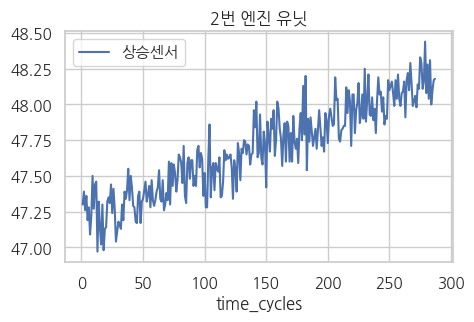

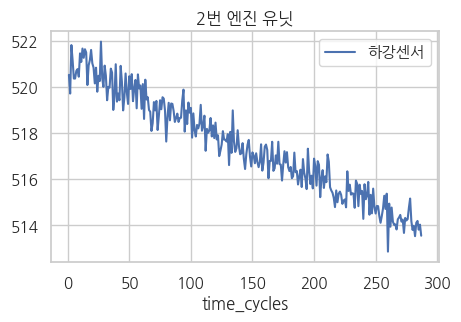

In [35]:
# 우선 seaborn 대신 plt로 가볍게 시작해봅시다
# X축(시간의 흐름) : time_cycles
# Y축(결과) : 상승센서 : s_11, 하강센서 : s_7, s_12

plt.figure(figsize=(5, 3))
plt.title('2번 엔진 유닛')
plt.plot(engine2['time_cycles'], engine2['s_11'], label='상승센서')
plt.xlabel('time_cycles')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
plt.title('2번 엔진 유닛')
plt.plot(engine2['time_cycles'], engine2['s_12'], label='하강센서')
plt.xlabel('time_cycles')
plt.legend()
plt.show()

## 실습 7. 여러 센서 비교와 범위 문제
여러 센서를 함께 그려 값 범위 차이 문제를 체험

목표
- 여러 센서를 함께 그려 비교하고 값 범위가 다를 때의 문제를 체험

단계
- 크기가 비슷한 두 센서를 함께 그리고 범례를 붙여 비교
- 크기가 크게 다른 두 센서를 일부러 겹쳐 그리기
- 두 센서의 범위를 숫자로 확인해 작은 값이 왜 안 보이는지 이해

예상 결과
- 약 8100 센서에 가려 약 38 센서가 평평하게 보임

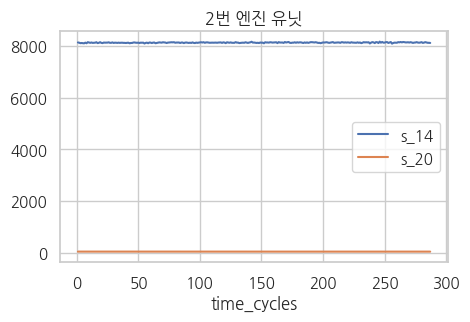

              s_14        s_20
count   287.000000  287.000000
mean   8138.262334   38.452787
std      11.930483    0.273305
min    8099.120000   37.880000
25%    8130.815000   38.230000
50%    8138.290000   38.450000
75%    8145.940000   38.655000
max    8176.360000   39.060000


In [52]:
#  s_2와 s_7은 수치 범위가 수백 단위로 비슷하여 한 차트 안에서 둘 다 거동 파악이 가능합니다.
# 하지만 s_14(약 8100 대)와 s_20(약 38 대)처럼 스케일이 극도로 다른 두 센서를 한 도화지에 겹치면,
# y축 범위가 크게 벌어져 상대적으로 범위가 좁은 s_20은 완전히 수평선처럼 찌그러져 보이는 문제가 발생합니다.
# 이러한 스케일 격차 문제를 극복하려면 정규화(Normalization) 전처리 또는 이중 y축(twinx)을 사용해야 합니다.

plt.figure(figsize=(5, 3))
plt.title('2번 엔진 유닛')
plt.plot(engine2['time_cycles'], engine2['s_14'], label='s_14')
plt.plot(engine2['time_cycles'], engine2['s_20'], label='s_20')
plt.xlabel('time_cycles')
plt.legend()
plt.show()

print(engine2[['s_14', 's_20']].describe())


## 실습 8. 데이터 구조 미니 리포트
오늘 확인한 크기·엔진·센서 특성을 짧은 리포트로 정리

목표
- 오늘 확인한 크기·엔진·센서 특성을 짧은 리포트로 자동 정리

단계
- 전체 크기와 엔진 대수를 한 줄로 출력
- 대상 엔진의 작동 회차 수와 결측 유무를 정리
- 주목 센서 세 개의 첫·끝 방향을 반복문으로 표처럼 정리

예상 결과
- 크기·엔진 수·회차·결측·센서 방향이 담긴 짧은 명세 리포트

In [59]:
# 전체 크기와 엔진 대수를 한 줄로 출력
print(f'전체크기 : {df.shape}')
print(f'엔진대수 : {df['unit_nr'].nunique()}대')
print(f'데이터유실 : {df.isna().sum().sum()}개')

target = 2 # 2번 유닛만 대상으로 함
print(f'대상엔진 : {target}번')

engine = df[df['unit_nr'] == target]
print(f'엔진 {target} : {len(engine)}회차 기록됨, 결측 {engine.isna().sum().sum()}개')

for sensor in ['s_11', 's_7', 's_12']:
  start = engine[sensor].iloc[0]
  end = engine[sensor].iloc[-1]
  print(f'{sensor}의 데이터는 {start}로 시작해서 {end}로 끝납니다.')

전체크기 : (1116, 26)
엔진대수 : 5대
데이터유실 : 0개
대상엔진 : 2번
엔진 2 : 287회차 기록됨, 결측 0개
s_11의 데이터는 47.3로 시작해서 48.18로 끝납니다.
s_7의 데이터는 553.84로 시작해서 546.17로 끝납니다.
s_12의 데이터는 520.52로 시작해서 513.55로 끝납니다.
